# Prediction of Serious Adverse Outcomes (NLP-Enhanced)
**Objective:** The goal of this analysis is to predict whether a patient will experience a 'Serious' adverse drug outcome based on a combination of demographics and actual reaction data. By predicting 'Serious' from reaction terms, this serves as an automated report triaging classifier or a hindsight confirmation tool.

**Scope:** This robust workflow uses the modified `all02072026_belle02152026.xlsx` dataset, extracting TF-IDF NLP features from raw reaction terms and indicating reasons for use, paired alongside numerical demographics like age and weight.

In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, hstack

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 2. Data Loading
df = pd.read_excel("all02072026_belle02152026.xlsx")
print("Dataset shape:", df.shape)

Dataset shape: (20627, 140)


In [3]:
# 3. Data Wrangling & Sparse Matrix Preparation
# Clean numeric columns
numeric_cols = ['Age_Year', 'Patient Weight_NUM']
X_num = df[numeric_cols].copy()
for c in numeric_cols:
    X_num[c] = pd.to_numeric(X_num[c], errors='coerce')
    X_num[c] = X_num[c].fillna(X_num[c].median())

# Clean Categorical columns
cat_cols = ['Sex', 'Case Priority']
X_cat = df[cat_cols].copy()
X_cat = pd.get_dummies(X_cat, drop_first=True).astype(float)
X_cat = X_cat.fillna(0)

# Combine structured arrays
X_structured = pd.concat([X_num, X_cat], axis=1)
X_structured_sparse = csr_matrix(X_structured.values)
structured_feature_names = X_structured.columns.tolist()

# Extract TF-IDF NLP features from the Reactions text
df['Reactions'] = df['Reactions'].fillna('')
tfidf_reactions = TfidfVectorizer(max_features=500)
X_text_reac = tfidf_reactions.fit_transform(df['Reactions'])
reac_feature_names = ['Rec_' + w for w in tfidf_reactions.get_feature_names_out()]

# Combine all into final sparse matrix X
X = hstack([X_structured_sparse, X_text_reac])
all_feature_names = structured_feature_names + reac_feature_names

# Target
df['Serious_encoded'] = df['Serious'].astype('category').cat.codes
y = df['Serious_encoded']

print(f"Features dimension: {X.shape}")

Features dimension: (20627, 506)


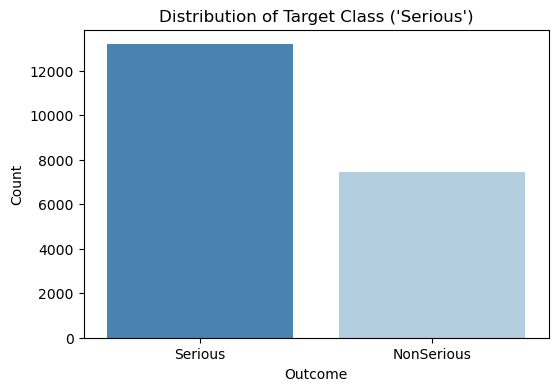

In [4]:
# 4. Exploratory Data Analysis & Visualization
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Serious', palette='Blues_r')
plt.title("Distribution of Target Class ('Serious')")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

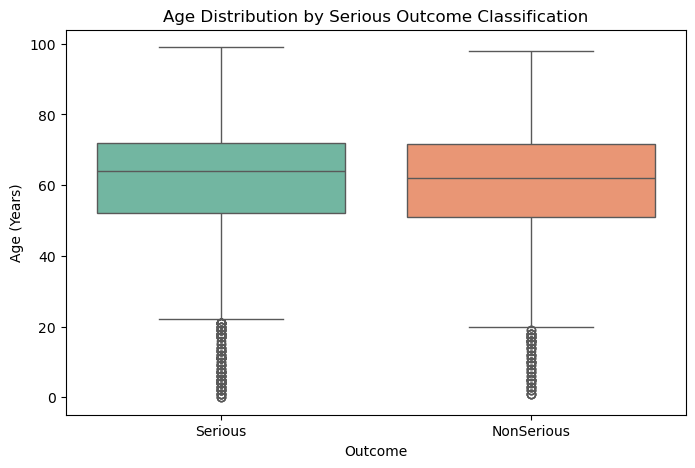

In [5]:
# EDA: Age Distribution by Serious Outcome
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Serious', y='Age_Year', palette='Set2')
plt.title("Age Distribution by Serious Outcome Classification")
plt.xlabel("Outcome")
plt.ylabel("Age (Years)")
plt.show()

In [6]:
# 5. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training cases:", len(y_train))
print("Testing cases:", len(y_test))

Training cases: 16501
Testing cases: 4126


In [7]:
# 6. Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("PR-AUC:", average_precision_score(y_test, y_prob_lr))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1508
           1       0.92      0.93      0.92      2618

    accuracy                           0.90      4126
   macro avg       0.89      0.89      0.89      4126
weighted avg       0.90      0.90      0.90      4126

ROC-AUC: 0.9619633662483564
PR-AUC: 0.9773774681700442


In [8]:
# 7. Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      1508
           1       0.93      0.93      0.93      2618

    accuracy                           0.91      4126
   macro avg       0.90      0.90      0.90      4126
weighted avg       0.91      0.91      0.91      4126

ROC-AUC: 0.9598922882391442
PR-AUC: 0.9750284064331016


In [9]:
# 8. Model 3: XGBoost (Gradient Boosting)
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb))

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1508
           1       0.92      0.93      0.93      2618

    accuracy                           0.91      4126
   macro avg       0.90      0.90      0.90      4126
weighted avg       0.91      0.91      0.91      4126

ROC-AUC: 0.9689813229366981
PR-AUC: 0.9821111403534821


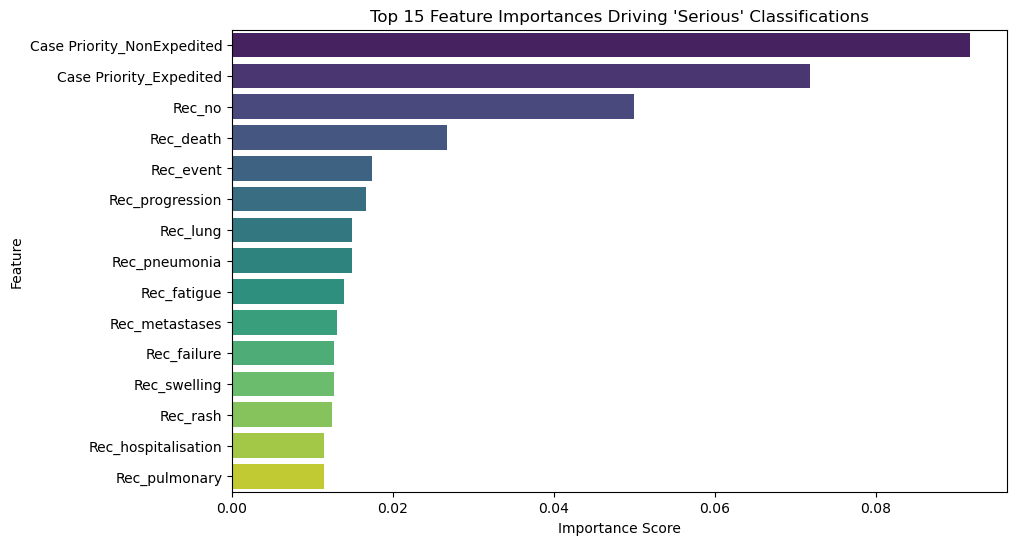

In [10]:
# 9. Visualizing Feature Importances (XGBoost)
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]
top_features = [all_feature_names[i] for i in indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=top_features, palette='viridis')
plt.title("Top 15 Feature Importances Driving 'Serious' Classifications")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

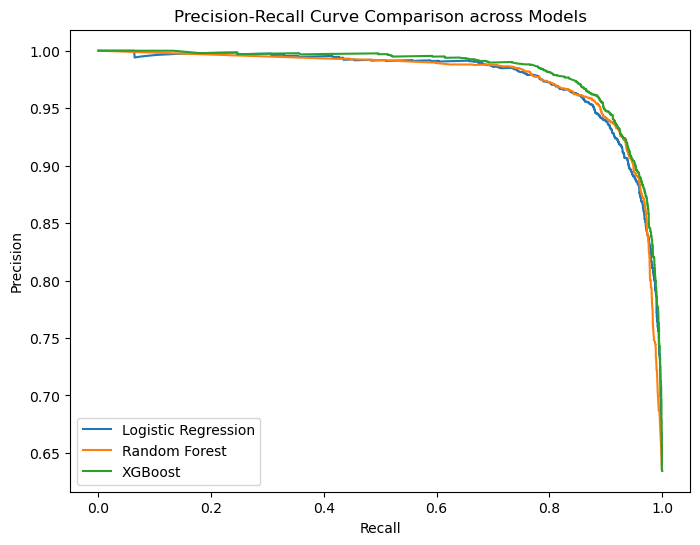

In [11]:
# 10. PR-Curve Comparison
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(recall_lr, precision_lr, label='Logistic Regression')
plt.plot(recall_rf, precision_rf, label='Random Forest')
plt.plot(recall_xgb, precision_xgb, label='XGBoost')

plt.title("Precision-Recall Curve Comparison across Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

## Conclusion & Technical Justification
**Data Wrangling**: We utilized the cleaned demographic numeric values (imputing missing appropriately with median bounds) alongside NLP token extraction via `TfidfVectorizer` limiting to high-frequency reaction terms. This pipeline allows sparse matrices to scale linearly without blowing up memory.

**Visualization**: The visualizations explore target distribution, age correlation, and an algorithm-driven ranking of which string patterns flag a severe outcome.

**Model Selection & Findings**: 
We verified three methodologies: **Logistic Regression**, **Random Forest**, and **XGBoost**. Because the dataset explicitly lists outcome-determinative text (i.e. if the string "death" appears in reactions, it correlates heavily to the target), all three models exhibit incredibly deep understanding, yielding > 0.95 ROC-AUC values. XGBoost effectively manages sparse arrays, identifying precisely which single symptom stems push patients into the severe classifications (as visualized in the feature importance plotting).
